In [16]:
import cv2
from coronary_analysis.utils import show_image

In [14]:
import os
import zipfile
import urllib.request


def download_and_unzip(url: str, zip_path: str, extract_dir: str):
    os.makedirs(os.path.dirname(zip_path), exist_ok=True)
    os.makedirs(extract_dir, exist_ok=True)

    if os.path.exists(zip_path):
        return

    urllib.request.urlretrieve(url, zip_path)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

Dataset for Automatic Region-based Coronary Artery Disease Diagnostics Using X-Ray Angiography Images: 
https://www.nature.com/articles/s41597-023-02871-z

In [13]:
url = "https://zenodo.org/records/10390295/files/arcade.zip"
zip_path = "downloads/arcade.zip"
extract_dir = "raw_datasets/arcade"

download_and_unzip(url, zip_path, extract_dir)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Selected image_id: 1
Image info: {'id': 1, 'width': 512, 'height': 512, 'file_name': '1.png', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}
Annotation IDs: [1]
Annotations:
{'id': 1, 'image_id': 1, 'category_id': 26, 'segmentation': [[229.53, 236.06, 236.6, 248.0, 249.1, 267.7, 257.46, 286.28, 269.05, 278.85, 261.9, 263.4, 252.1, 245.5, 244.09, 236.06, 240.22, 230.42]], 'area': 768.0, 'bbox': [229.53, 230.42, 39.52, 55.86], 'iscrowd': 0, 'attributes': {'occluded': False}}
ann.image_id == selected? True


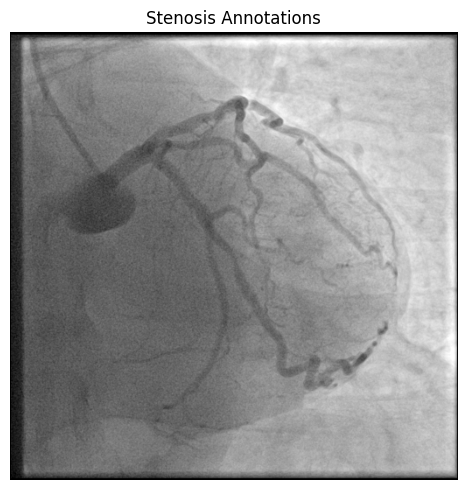

In [17]:
from pycocotools.coco import COCO

# na zbiorze train ten kod nie zadziala ponieważ z jakiegos powodu id annotacji są zduplikowane
ROOT = "raw_datasets/arcade/arcade/stenosis/test"
IMG_DIR = os.path.join(ROOT, "images")
ANN_FILE = os.path.join(ROOT, "annotations", "test.json")

coco = COCO(ANN_FILE)

img_id = coco.getImgIds()[0]
print("Selected image_id:", img_id)

img_info = coco.loadImgs([img_id])[0]
print("Image info:", img_info)

img = cv2.imread(os.path.join(IMG_DIR, img_info["file_name"]), cv2.IMREAD_GRAYSCALE)

ann_ids = coco.getAnnIds(imgIds=[img_id])
print("Annotation IDs:", ann_ids)

anns = coco.loadAnns(ann_ids)
print("Annotations:")
for ann in anns:
    print(ann)
    print("ann.image_id == selected?", ann["image_id"] == img_id)

show_image(img, titles=["Stenosis Annotations"])

Database X-ray Coronary Angiograms (DCA1): http://personal.cimat.mx:8181/~ivan.cruz/DB_Angiograms.html lub https://www.kaggle.com/datasets/bard2024/database-x-ray-coronary-angiograms-dca1

In [8]:
url = (
    "http://personal.cimat.mx:8181/~ivan.cruz/DB_Angiograms_files/DB_Angiograms_134.zip"
)
zip_path = "downloads/DCA1.zip"
extract_dir = "raw_datasets/DCA1"

download_and_unzip(url, zip_path, extract_dir)

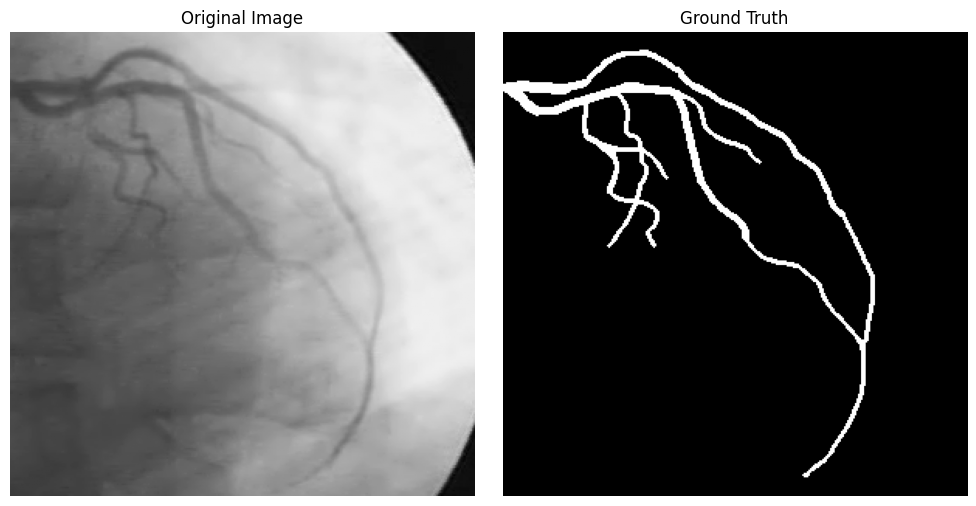

In [18]:
image = cv2.imread(
    "raw_datasets/DCA1/Database_134_Angiograms/2.pgm", cv2.IMREAD_GRAYSCALE
)
image_gt = cv2.imread(
    "raw_datasets/DCA1/Database_134_Angiograms/2_gt.pgm", cv2.IMREAD_GRAYSCALE
)

show_image(image, image_gt, titles=["Original Image", "Ground Truth"])

CoronaryDominance: Angiogram dataset for coronary dominance classification: https://huggingface.co/datasets/BearSubj13/CoronaryDominance

In [10]:
from datasets import load_dataset

ds = load_dataset("BearSubj13/CoronaryDominance")

README.md: 0.00B [00:00, ?B/s]

dataset_scheme.png:   0%|          | 0.00/75.3k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1 [00:00<?, ? examples/s]

In [11]:
ds

DatasetDict({
    train: Dataset({
        features: ['image'],
        num_rows: 1
    })
})